# 📊 EDA Report – Quant Analyst
**Workflow**: Load OHLCV → Rich Describe → Distributions → Rolling Volatility → Export HTML Report

---

In [1]:
from qtrader.output.analyst import AnalystSession, RoleContext
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.special import erfinv

session = AnalystSession(role=RoleContext.ANALYST)
session.info()

📊 Quant Analyst Workflow
  1. load_ohlcv / sample_ohlcv → load market data
  2. make_returns + add_rolling_features → prepare features
  3. run_vector_backtest → backtest a signal
  4. compute_extended_metrics → Sharpe, Sortino, Calmar, Win Rate
  5. export_report → save interactive HTML report

  📓 Notebooks: notebooks/analyst/01_EDA_Report.ipynb, ...



## 1. Load Data

In [2]:
SYMBOL = "BTC-USD"
TIMEFRAME = "1d"

try:
    df = session.load_ohlcv(SYMBOL, TIMEFRAME, days=365)
    if len(df) < 50:  # Too few rows for rolling features — use synthetic data
        raise ValueError(f"Insufficient data: only {len(df)} rows")
    print(f"Loaded {len(df)} rows from datalake")
except Exception as e:
    print(f"Falling back to synthetic data: {e}")
    df = session.sample_ohlcv(symbol="BTC", days=730)
    print(f"Using synthetic data: {len(df)} rows")

df.head(5)

Loaded 365 rows from datalake


timestamp,open,high,low,close,volume,symbol,tf
"datetime[μs, Asia/Ho_Chi_Minh]",f64,f64,f64,f64,f64,str,str
2025-03-17 07:00:00 +07,82562.5,84758.46,82416.98,84011.4,7785.977334,"""BTC-USD""","""1d"""
2025-03-18 07:00:00 +07,84011.39,84029.67,81125.0,82698.76,7316.632966,"""BTC-USD""","""1d"""
2025-03-19 07:00:00 +07,82699.53,87045.45,82535.53,86877.96,13056.035199,"""BTC-USD""","""1d"""
2025-03-20 07:00:00 +07,86877.97,87492.87,83596.75,84183.42,9880.316963,"""BTC-USD""","""1d"""
2025-03-21 07:00:00 +07,84183.41,84809.72,83100.0,84061.96,6257.635588,"""BTC-USD""","""1d"""


## 2. Rich Descriptive Statistics

In [3]:
df = session.make_returns(df)
df = session.add_rolling_features(df, windows=[5, 14, 21])
df = df.drop_nulls()  # Drop NaNs from rolling windows before analysis
assert len(df) > 0, "DataFrame is empty after feature engineering — check data source"
stats_df = session.rich_describe_table(df)
stats_df

column,count,mean,std,min,q25,median,q75,max,skew,kurtosis,null_pct,outlier_pct (IQR)
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""open""",345,98935.443768,15774.684892,62788.28,88310.6,103786.4,111546.61,124723.57,-0.5594,-0.6868,0.0,0.0
"""high""",345,100449.636029,15700.212318,64988.32,90064.74,105266.61,113357.0,126296.0,-0.543,-0.7024,0.0,0.0
"""low""",345,97271.423623,15872.668956,60001.0,87077.17,102105.0,109945.86,123115.77,-0.5687,-0.6829,0.0,0.0
"""close""",345,98906.118261,15812.635016,62791.0,88310.6,103786.43,111549.32,124720.09,-0.5594,-0.6959,0.0,0.0
"""volume""",345,7967.980272,5614.292423,1227.768033,4615.458351,7050.611519,9840.74408,49371.205791,2.6747,13.2925,0.0,4.93
…,…,…,…,…,…,…,…,…,…,…,…,…
"""sma_21""",345,99317.582469,14743.579178,67325.775238,89380.067143,105365.4,112703.929524,118220.609524,-0.5633,-0.7148,0.0,0.0
"""vol_21""",345,3515.255873,1703.73966,955.040635,2305.882971,2762.863215,4536.503815,8996.125416,1.2006,0.9038,0.0,3.19
"""avg_gain""",345,0.00782,0.00324,0.002565,0.005451,0.007115,0.010086,0.020301,0.8087,-1.3013,0.0,0.58


## 3. Returns Distribution

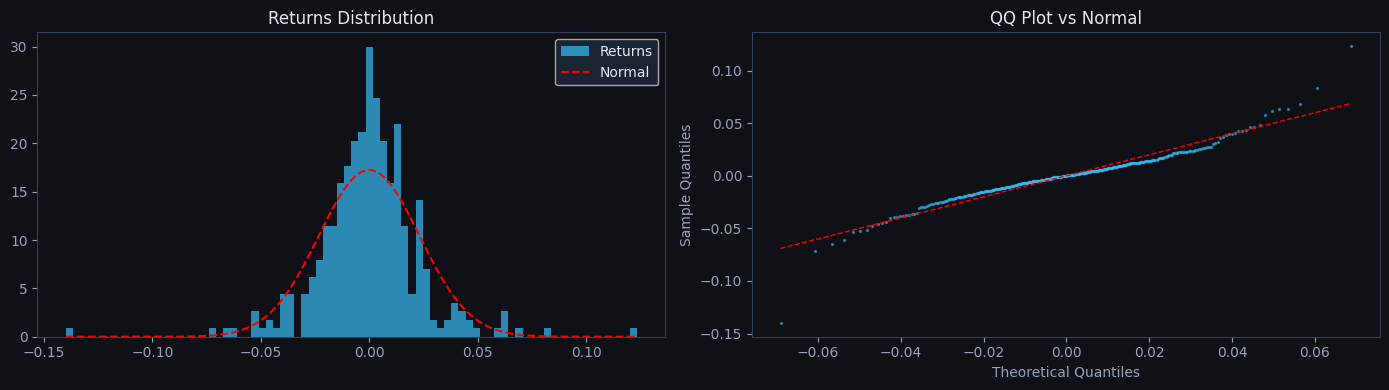

In [4]:
returns = df['returns'].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0f1117')
for ax in axes:
    ax.set_facecolor('#0f1117')
    for spine in ax.spines.values():
        spine.set_color('#334155')
    ax.tick_params(colors='#94a3b8')

# Histogram + KDE
axes[0].hist(returns, bins=80, color='#38bdf8', alpha=0.7, density=True, label='Returns')
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 300)
axes[0].plot(x, np.exp(-0.5*((x-mu)/sigma)**2)/(sigma*np.sqrt(2*np.pi)), 'r--', linewidth=1.5, label='Normal')
axes[0].set_title('Returns Distribution', color='#e2e8f0')
axes[0].legend(facecolor='#1e293b', labelcolor='#e2e8f0')

# QQ-plot approximation
sorted_r = np.sort(returns)
n = len(sorted_r)
quantiles = np.array([(i+0.5)/n for i in range(n)])
normal_q = mu + sigma * np.sqrt(2) * np.array([erfinv(2*p-1) for p in quantiles])
axes[1].scatter(normal_q, sorted_r, s=2, color='#38bdf8', alpha=0.5)
axes[1].plot([normal_q[0], normal_q[-1]], [normal_q[0], normal_q[-1]], 'r--', linewidth=1)
axes[1].set_title('QQ Plot vs Normal', color='#e2e8f0')
axes[1].set_xlabel('Theoretical Quantiles', color='#94a3b8')
axes[1].set_ylabel('Sample Quantiles', color='#94a3b8')

plt.tight_layout()
plt.show()
dist_fig = fig

## 4. Rolling Volatility & Price

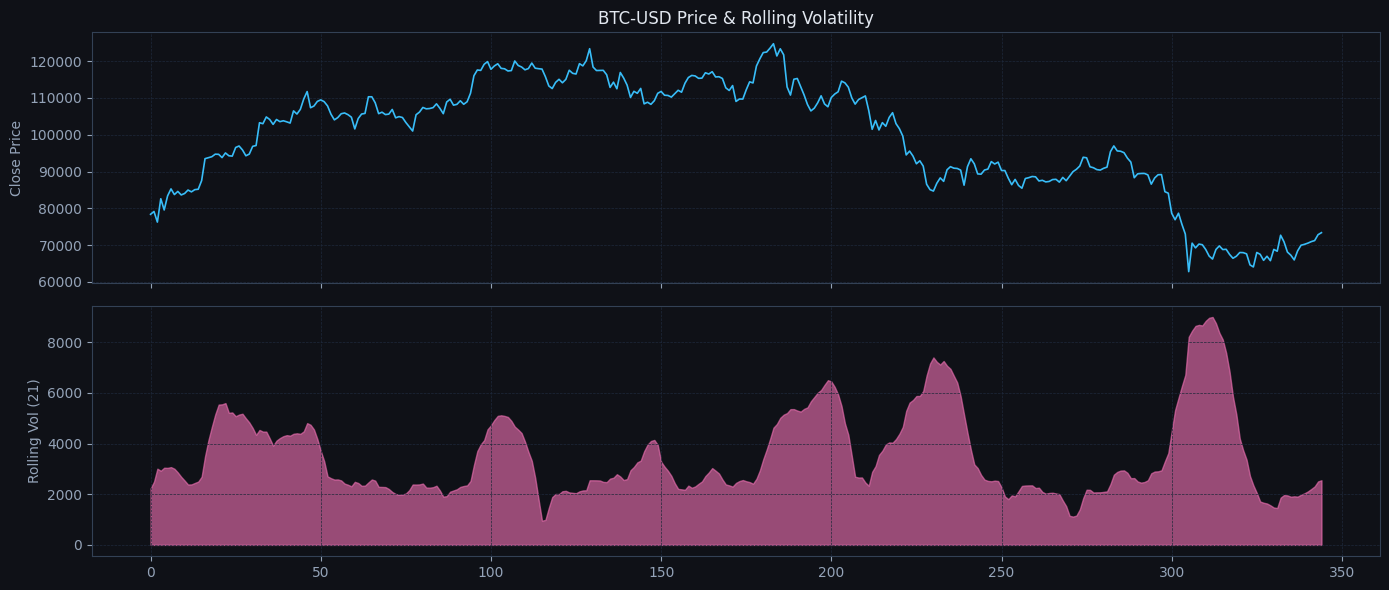

In [5]:
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), facecolor='#0f1117', sharex=True)
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1117')
    for spine in ax.spines.values(): spine.set_color('#334155')
    ax.tick_params(colors='#94a3b8')
    ax.grid(color='#1e293b', linestyle='--', linewidth=0.5)

close = df['close'].to_numpy()
ax1.plot(close, color='#38bdf8', linewidth=1.2)
ax1.set_ylabel('Close Price', color='#94a3b8')
ax1.set_title(f'{SYMBOL} Price & Rolling Volatility', color='#e2e8f0')

if 'vol_21' in df.columns:
    vol21 = df['vol_21'].to_numpy()
    ax2.fill_between(range(len(vol21)), vol21, alpha=0.6, color='#f472b6')
    ax2.set_ylabel('Rolling Vol (21)', color='#94a3b8')

plt.tight_layout()
plt.show()
vol_fig = fig2

## 5. Export HTML Report

In [6]:
out_path = session.export_report(
    title=f"EDA Report – {SYMBOL} {TIMEFRAME}",
    sections={
        "Overview": f"Symbol: {SYMBOL} | Timeframe: {TIMEFRAME} | Rows: {len(df)}",
        "Descriptive Statistics": stats_df,
        "Returns Distribution": dist_fig,
        "Price & Rolling Volatility": vol_fig,
    },
    path=f"reports/{SYMBOL.replace('-','_')}_EDA.html",
)
print(f"✅ Report saved: {out_path}")

✅ Report saved: reports/BTC_USD_EDA.html
